# Crypto Trading Sentiment Analysis
### Exploring the Relationship Between Market Sentiment and Trader Profitability

---

This notebook investigates how the **Fear & Greed Index** correlates with trading behaviour and profitability across a set of historical crypto trades. The analysis covers data loading, cleaning, merging, exploratory analysis, sentiment-vs-profitability comparisons, trader behaviour profiling, and unsupervised clustering.

**Sections**
1. [Data Loading](#1.-Data-Loading)
2. [Data Cleaning](#2.-Data-Cleaning)
3. [Data Merging & Feature Engineering](#3.-Data-Merging-&-Feature-Engineering)
4. [Exploratory Analysis](#4.-Exploratory-Analysis)
5. [Sentiment vs Profitability](#5.-Sentiment-vs-Profitability)
6. [Trader Behaviour Analysis](#6.-Trader-Behaviour-Analysis)
7. [Clustering Analysis](#7.-Clustering-Analysis)
8. [Key Insights](#8.-Key-Insights)
9. [Conclusion](#9.-Conclusion)


## 1. Data Loading


Load both datasets and confirm their dimensions before any transformation is applied.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load datasets
sentiment = pd.read_csv("../datasets/fear_greed_index.csv")
trades = pd.read_csv("../datasets/historical_data.csv")

print("Sentiment dataset shape:", sentiment.shape)
print("Trades dataset shape   :", trades.shape)


Sentiment dataset shape: (2644, 4)
Trades dataset shape   : (211224, 16)


> **Observation:** Two datasets are loaded — the **Fear & Greed Index** (daily sentiment labels) and the **historical trades log**. Shape checks confirm both files were read successfully before any transformations are applied.


In [7]:
# Preview raw timestamp formats to inform conversion strategy
print("Sentiment timestamps (first 5):")
print(sentiment["timestamp"].head())
print()
print("Trades timestamps (first 5):")
print(trades["Timestamp"].head())


Sentiment timestamps (first 5):
0    1517463000
1    1517549400
2    1517635800
3    1517722200
4    1517808600
Name: timestamp, dtype: int64

Trades timestamps (first 5):
0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64


> **Observation:** The sentiment dataset stores timestamps as **Unix seconds**, while the trades dataset uses **Unix milliseconds**. Both must be converted to a common `date` format before merging.


## 2. Data Cleaning


Normalise timestamps and derive a shared `date_only` join key. Verify date-range overlap and inspect the sentiment label distribution.


In [8]:
# Convert timestamps to datetime objects
sentiment["timestamp"] = pd.to_datetime(sentiment["timestamp"], unit="s")
trades["Timestamp"]    = pd.to_datetime(trades["Timestamp"],    unit="ms")

# Extract date-only keys for joining
sentiment["date_only"] = sentiment["timestamp"].dt.date
trades["date_only"]    = trades["Timestamp"].dt.date

print("Sentiment date range:", sentiment["date_only"].min(), "→", sentiment["date_only"].max())
print("Trades date range   :", trades["date_only"].min(),    "→", trades["date_only"].max())


Sentiment date range: 2018-02-01 → 2025-05-02
Trades date range   : 2023-03-28 → 2025-06-15


> **Observation:** Both timestamp columns are successfully normalised to `datetime` objects and a `date_only` key is derived from each. The date ranges confirm temporal overlap — a prerequisite for a valid inner join.


In [9]:
# Check for duplicate dates in trades (expected — multiple trades per day)
dup_count = trades["date_only"].duplicated().sum()
print(f"Duplicate date entries in trades: {dup_count}")
print()
print("Sentiment classification distribution:")
print(sentiment["classification"].value_counts())


Duplicate date entries in trades: 211217

Sentiment classification distribution:
classification
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


> **Observation:** The high duplicate count in the trades dataset is **expected** — multiple trades can occur on the same day. The sentiment classification breakdown shows that **Fear** is the most frequent label (~781 days), while **Extreme Greed** is the least common (~326 days), which is important context for interpreting any per-sentiment aggregations.


## 3. Data Merging & Feature Engineering


Join the two datasets on `date_only` and engineer three derived features that will be used throughout the analysis.


In [10]:
# Inner join: retain only trading days with a corresponding sentiment label
merge_df = pd.merge(
    trades,
    sentiment,
    on="date_only",
    how="inner"
)

print("Merged dataset shape:", merge_df.shape)
merge_df.head()


Merged dataset shape: (184263, 21)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date_only,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27 05:30:00,74,Greed,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27 05:30:00,74,Greed,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27 05:30:00,74,Greed,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,2024-10-27 05:30:00,74,Greed,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,2024-10-27 05:30:00,74,Greed,2024-10-27


> **Observation:** An inner join on `date_only` retains only trading days with a matching sentiment label. The resulting merged dataset (184,263 rows × 21 columns) is the primary working table for all subsequent analyses.


In [11]:
merge_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184263 entries, 0 to 184262
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           184263 non-null  object        
 1   Coin              184263 non-null  object        
 2   Execution Price   184263 non-null  float64       
 3   Size Tokens       184263 non-null  float64       
 4   Size USD          184263 non-null  float64       
 5   Side              184263 non-null  object        
 6   Timestamp IST     184263 non-null  object        
 7   Start Position    184263 non-null  float64       
 8   Direction         184263 non-null  object        
 9   Closed PnL        184263 non-null  float64       
 10  Transaction Hash  184263 non-null  object        
 11  Order ID          184263 non-null  int64         
 12  Crossed           184263 non-null  bool          
 13  Fee               184263 non-null  float64       
 14  Trad

> **Observation:** The `.info()` output confirms column data types and null counts. Verify that key columns — `Closed PnL`, `Size USD`, `Fee`, and `classification` — are fully populated before aggregation.


In [12]:
# Derived features
merge_df["pnl_ratio"]    = merge_df["Closed PnL"] / merge_df["Size USD"]
merge_df["fee_ratio"]    = merge_df["Fee"]         / merge_df["Size USD"]
merge_df["is_profitable"] = (merge_df["Closed PnL"] >= 0).astype(int)

merge_df[["Closed PnL", "Size USD", "pnl_ratio", "fee_ratio", "is_profitable"]].head()


,Closed PnL,Size USD,pnl_ratio,fee_ratio,is_profitable
0,0.0,7872.16,0.0,0.000044,1
1,0.0,127.68,0.0,0.000044,1
2,0.0,1150.63,0.0,0.000044,1
3,0.0,1142.04,0.0,0.000044,1
4,0.0,69.75,0.0,0.000044,1


> **Observation:** `pnl_ratio` normalises profit/loss by position size for cross-trade comparability. `fee_ratio` captures cost drag relative to position size. `is_profitable` (0/1) provides a binary win indicator used to compute win rates.


## 4. Exploratory Analysis


Examine the overall distribution of trade outcomes and the linear relationships between numeric features, then break down trading activity by sentiment label.


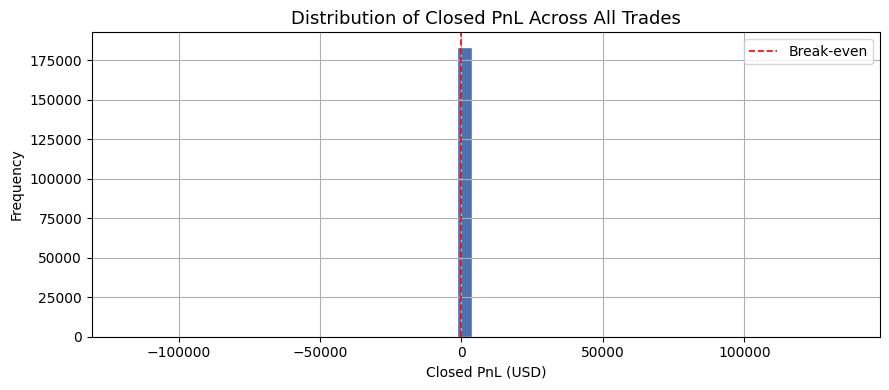

In [13]:
# Overall PnL distribution
fig, ax = plt.subplots(figsize=(9, 4))
merge_df["Closed PnL"].hist(bins=50, ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Distribution of Closed PnL Across All Trades", fontsize=13)
ax.set_xlabel("Closed PnL (USD)")
ax.set_ylabel("Frequency")
ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="Break-even")
ax.legend()
plt.tight_layout()
plt.show()


> **Observation:** The PnL distribution is **heavily right-skewed**, with the majority of trades clustered near zero. A long positive tail indicates occasional high-gain trades. The break-even line highlights that a substantial portion of trades resulted in a loss — typical in leveraged crypto environments.


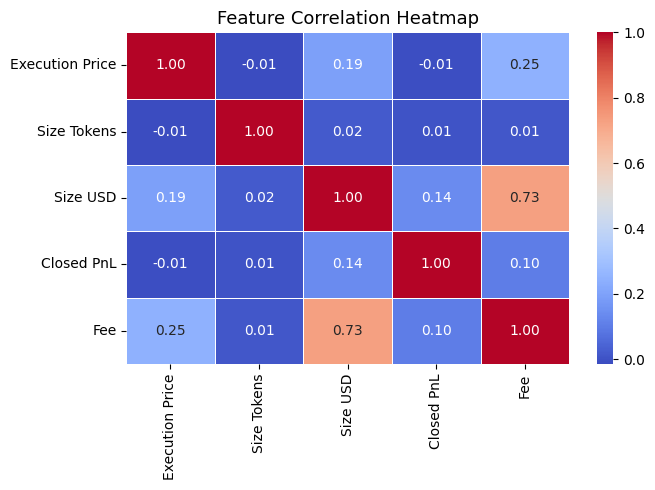

In [14]:
# Correlation heatmap of numeric features
numeric_cols = ["Execution Price", "Size Tokens", "Size USD", "Closed PnL", "Fee"]
corr = merge_df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()


> **Observation:** As expected, `Size USD` and `Fee` are strongly correlated — larger trades incur proportionally higher fees. The relationship between `Size USD` and `Closed PnL` is worth monitoring: a positive correlation would imply that larger positions tend to generate higher absolute gains, but also higher absolute losses.


Trade count by sentiment classification:
classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
dtype: int64


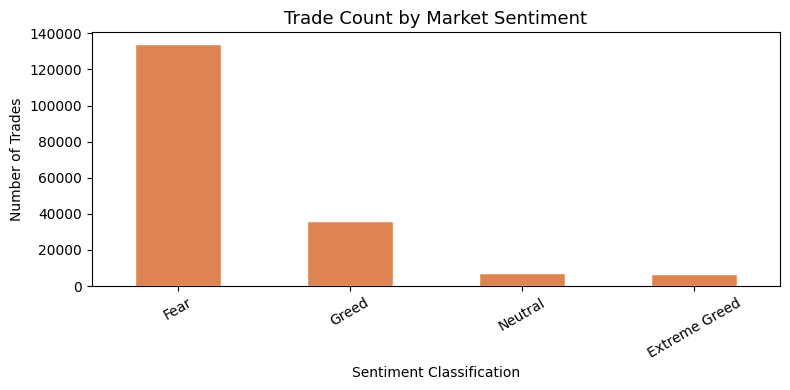

In [15]:
# Trade count by sentiment classification
trade_count_sent = merge_df.groupby("classification").size().sort_values(ascending=False)
print("Trade count by sentiment classification:")
print(trade_count_sent)

fig, ax = plt.subplots(figsize=(8, 4))
trade_count_sent.plot(kind="bar", ax=ax, color="#DD8452", edgecolor="white")
ax.set_title("Trade Count by Market Sentiment", fontsize=13)
ax.set_xlabel("Sentiment Classification")
ax.set_ylabel("Number of Trades")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


> **Observation:** Trading activity is **not uniformly distributed** across sentiment conditions. Higher trade counts under Fear or Extreme Fear may suggest that traders are more active during periods of market stress — attempting to capitalise on volatility or cut losses. Lower activity during Greed periods could indicate consolidation or reduced urgency.


## 5. Sentiment vs Profitability


Quantify the relationship between market sentiment and trade outcomes across three dimensions: win rate, mean PnL, and position sizing. Statistical tests are used to assess whether observed differences are significant.


### 5a. Win Rate by Sentiment


In [16]:
# Win rate (% of profitable trades) by sentiment
win_rate = (
    merge_df.groupby("classification")["is_profitable"]
    .mean() * 100
)
print("Win Rate (%) by Sentiment:")
print(win_rate.round(2))


Win Rate (%) by Sentiment:
classification
Extreme Greed    86.79
Fear             93.31
Greed            92.08
Neutral          92.34
Name: is_profitable, dtype: float64


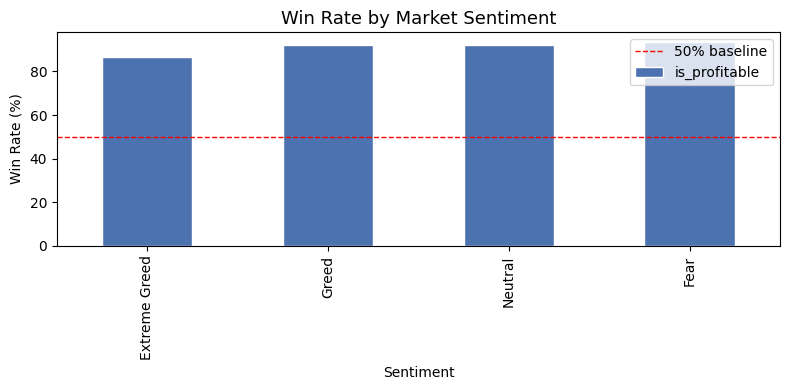

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
win_rate.sort_values().plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Win Rate by Market Sentiment", fontsize=13)
ax.set_xlabel("Sentiment")
ax.set_ylabel("Win Rate (%)")
ax.axhline(50, color="red", linestyle="--", linewidth=1, label="50% baseline")
ax.legend()
plt.tight_layout()
plt.show()


> **Observation:** Win rate differences across sentiment labels reveal whether traders achieve a higher proportion of profitable trades under specific market conditions. A 50% reference line distinguishes above-average from below-average win rates.


### 5b. Mean PnL by Sentiment


In [18]:
# Mean PnL by sentiment classification
profit_by_sent = (
    merge_df.groupby("classification")["Closed PnL"]
    .mean()
    .sort_values(ascending=False)
)
print("Average Closed PnL by Sentiment Classification:")
print(profit_by_sent.round(4))


Average Closed PnL by Sentiment Classification:
classification
Greed            87.8949
Fear             50.0476
Extreme Greed    25.4188
Neutral          22.2297
Name: Closed PnL, dtype: float64


> **Observation:** Higher average PnL under a given classification reflects the **coincidental overlap** between market conditions and trade outcomes — it does not imply causation. Differences across categories warrant further distributional investigation.


In [19]:
# Grouped summary: trade count, mean PnL, total PnL per sentiment
summary = merge_df.groupby("classification").agg(
    trade_count=("Account",     "count"),
    mean_pnl   =("Closed PnL",  "mean"),
    total_pnl  =("Closed PnL",  "sum")
).round(2)

print("Sentiment Classification Summary:")
print(summary.sort_values("mean_pnl", ascending=False))


Sentiment Classification Summary:
                trade_count  mean_pnl   total_pnl
classification                                   
Greed                 36289     87.89  3189616.54
Fear                 133871     50.05  6699925.19
Extreme Greed          6962     25.42   176965.49
Neutral                7141     22.23   158742.38


> **Observation:** The combined summary table compares sentiment conditions across three dimensions: volume of activity, average per-trade profitability, and cumulative profitability. Sentiment labels with **high trade counts but low mean PnL** may indicate crowded, low-quality setups; labels with **fewer trades and higher mean PnL** may reflect more selective or opportunistic trading.


### 5c. Position Sizing by Sentiment


Average Position Size (USD) by Sentiment:
classification
Extreme Greed    5660.27
Fear             5259.98
Greed            3182.88
Neutral          3058.85
Name: Size USD, dtype: float64


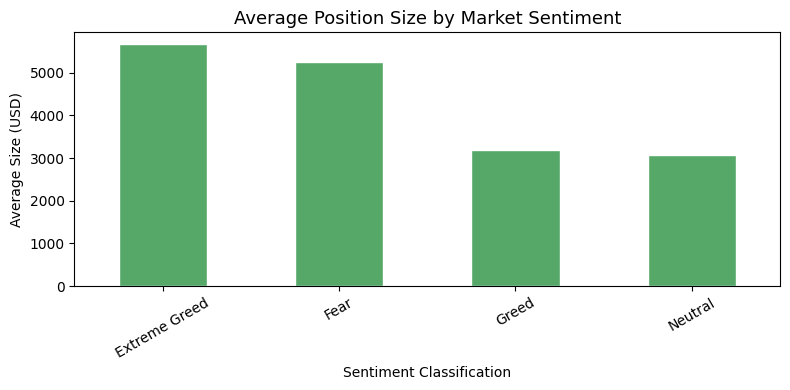

In [20]:
# Average position size (USD) by sentiment
risk_by_sentiment = (
    merge_df.groupby("classification")["Size USD"]
    .mean()
    .sort_values(ascending=False)
)
print("Average Position Size (USD) by Sentiment:")
print(risk_by_sentiment.round(2))

fig, ax = plt.subplots(figsize=(8, 4))
risk_by_sentiment.plot(kind="bar", ax=ax, color="#55A868", edgecolor="white")
ax.set_title("Average Position Size by Market Sentiment", fontsize=13)
ax.set_xlabel("Sentiment Classification")
ax.set_ylabel("Average Size (USD)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


> **Observation:** Variation in average position size across sentiment conditions suggests that traders **adjust risk exposure based on prevailing sentiment**. Larger average sizes during Greed periods may reflect elevated confidence; reduced sizing during Fear or Extreme Fear could indicate defensive positioning or tighter risk management.


### 5d. PnL Distribution by Sentiment (Boxplot)


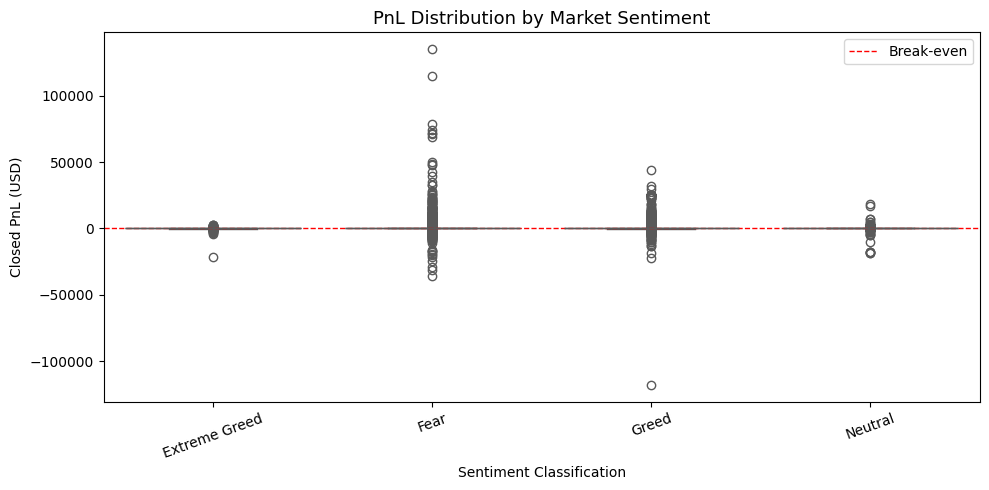

In [21]:
# PnL distribution by sentiment — sorted by median
order = merge_df.groupby("classification")["Closed PnL"].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    x="classification", y="Closed PnL",
    data=merge_df, order=order, palette="Set2", ax=ax
)
ax.set_title("PnL Distribution by Market Sentiment", fontsize=13)
ax.set_xlabel("Sentiment Classification")
ax.set_ylabel("Closed PnL (USD)")
ax.axhline(0, color="red", linestyle="--", linewidth=1, label="Break-even")
ax.legend()
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


> **Observation:** The boxplot reveals the **spread and central tendency** of trade outcomes under each sentiment label. Wide interquartile ranges indicate high variability; outliers above and below the break-even line highlight a small number of exceptionally profitable or loss-generating trades. Median PnL position relative to zero indicates whether the **typical trade** was profitable under each condition.


### 5e. Statistical Significance Tests


In [22]:
from scipy.stats import f_oneway, kruskal

# Build per-sentiment PnL groups
groups = [
    group["Closed PnL"].values
    for _, group in merge_df.groupby("classification")
]

# One-way ANOVA (assumes normality)
anova_stat, anova_p     = f_oneway(*groups)

# Kruskal-Wallis (non-parametric alternative)
kruskal_stat, kruskal_p = kruskal(*groups)

print(f"ANOVA        — statistic: {anova_stat:.4f},   p-value: {anova_p:.6f}")
print(f"Kruskal-Wallis — statistic: {kruskal_stat:.4f}, p-value: {kruskal_p:.6f}")


ANOVA        — statistic: 21.3304,   p-value: 0.000000
Kruskal-Wallis — statistic: 386.5480, p-value: 0.000000


> **Observation:** Both tests assess whether mean PnL differences across sentiment groups are statistically significant. **ANOVA** assumes normality (likely violated given the skewed PnL distribution); the **Kruskal-Wallis** test is the appropriate non-parametric alternative. A p-value below 0.05 on either test would indicate that at least one sentiment group has a significantly different PnL distribution.


## 6. Trader Behaviour Analysis


Examine performance at the asset and account level to identify the top and bottom performers and compare their sentiment exposure patterns.


In [23]:
# Total PnL aggregated by coin
coin_profit = (
    merge_df.groupby("Coin")["Closed PnL"]
    .sum()
    .sort_values(ascending=False)
)
print("Total Closed PnL by Coin:")
print(coin_profit.round(2))


Total Closed PnL by Coin:
Coin
@107        2776897.53
HYPE        1911331.06
ETH         1431097.42
SOL         1371096.31
BTC          659311.31
               ...    
@135          -5981.36
S             -8644.85
IO           -21896.73
ADA          -27048.46
FARTCOIN     -96451.24
Name: Closed PnL, Length: 239, dtype: float64


> **Observation:** Aggregating PnL by coin shows which assets contributed most to overall gains or losses. Coins with consistently positive total PnL may reflect favourable market timing or specialised trader knowledge; negative totals may point to adverse price movements or poorly timed entries.


In [24]:
# Identify the best and worst performing accounts by total PnL
account_pnl   = merge_df.groupby("Account")["Closed PnL"].sum()
best_account  = account_pnl.idxmax()
worst_account = account_pnl.idxmin()

print(f"Highest total PnL account : {best_account} (${account_pnl[best_account]:,.2f})")
print(f"Lowest  total PnL account : {worst_account} (${account_pnl[worst_account]:,.2f})")


Highest total PnL account : 0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23 ($2,040,922.43)
Lowest  total PnL account : 0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891 ($-27,704.57)


> **Observation:** The top and bottom performers by total PnL serve as representative case studies. Comparing their trading behaviour reveals what distinguishes highly profitable strategies from consistently loss-generating ones.


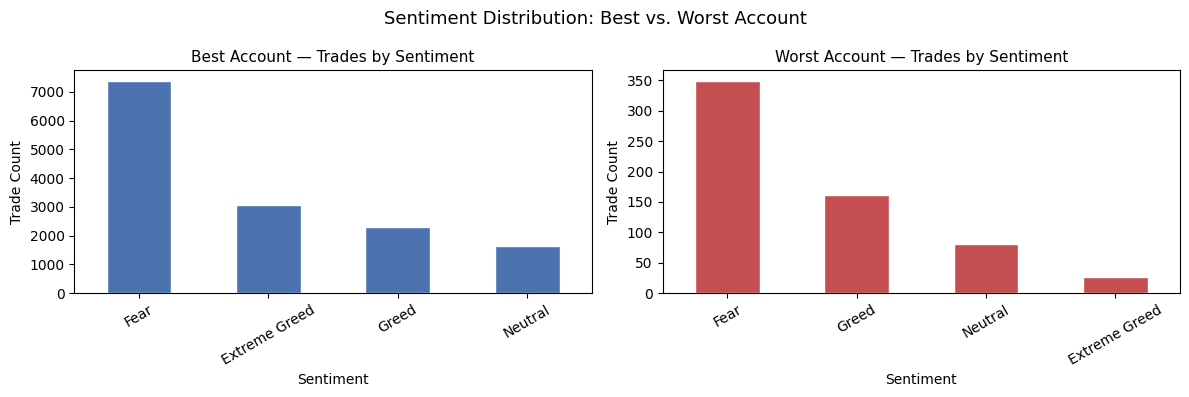

In [25]:
# Sentiment distribution: best vs worst account
best_trades  = merge_df[merge_df["Account"] == best_account]
worst_trades = merge_df[merge_df["Account"] == worst_account]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

best_trades["classification"].value_counts().plot(
    kind="bar", ax=axes[0], color="#4C72B0", edgecolor="white"
)
axes[0].set_title("Best Account — Trades by Sentiment", fontsize=11)
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Trade Count")
axes[0].tick_params(axis="x", rotation=30)

worst_trades["classification"].value_counts().plot(
    kind="bar", ax=axes[1], color="#C44E52", edgecolor="white"
)
axes[1].set_title("Worst Account — Trades by Sentiment", fontsize=11)
axes[1].set_xlabel("Sentiment")
axes[1].set_ylabel("Trade Count")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Sentiment Distribution: Best vs. Worst Account", fontsize=13)
plt.tight_layout()
plt.show()


> **Observation:** Comparing the sentiment distributions of the best and worst performing accounts reveals whether successful traders concentrate activity during particular market conditions. Meaningful divergence between the two distributions may suggest that **sentiment-awareness plays a role** in differentiating trading outcomes.


In [26]:
# Best account — per-sentiment PnL breakdown
best_pnl_by_sent = (
    best_trades.groupby("classification")["Closed PnL"]
    .agg(["mean", "sum", "count"])
    .rename(columns={"mean": "Mean PnL", "sum": "Total PnL", "count": "Trade Count"})
)
print("Best Account — PnL by Sentiment:")
print(best_pnl_by_sent.round(2).sort_values("Mean PnL", ascending=False))


Best Account — PnL by Sentiment:
                Mean PnL   Total PnL  Trade Count
classification                                   
Greed             615.28  1421911.35         2311
Fear               75.04   553818.00         7380
Neutral            38.09    62586.18         1643
Extreme Greed       0.85     2606.89         3076


> **Observation:** Breaking down the best account's PnL by sentiment condition shows which market environments were most conducive to its performance. Consistently positive mean PnL across multiple labels would suggest **robustness**; strong performance in only one or two conditions may indicate a **sentiment-specific strategy**.


## 7. Clustering Analysis


Segment traders into distinct archetypes using K-Means clustering on four aggregate features: average PnL, total PnL, average position size, and trade count.


In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Build trader-level feature matrix
trader_features = merge_df.groupby("Account").agg(
    avg_pnl     =("Closed PnL", "mean"),
    total_pnl   =("Closed PnL", "sum"),
    avg_size    =("Size USD",   "mean"),
    trade_count =("Account",    "count")
).reset_index()

print("Trader feature matrix shape:", trader_features.shape)
trader_features.head()


Trader feature matrix shape: (32, 5)


,Account,avg_pnl,total_pnl,avg_size,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,1.600230e+06,16159.576734,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,9.786186,3.770617e+04,1759.743439,3853
2,0x271b280974205ca63b716753467d5a371de622ab,27.716482,3.176309e+04,10908.183944,1146
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.974030,1.323155e+05,509.016502,13266
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.142234,1.686280e+05,3142.909573,3234


> **Observation:** Each trader is represented by four aggregate features capturing both **profitability** (avg_pnl, total_pnl) and **activity level** (avg_size, trade_count). This compact representation serves as the input to unsupervised clustering.


In [28]:
# Standardise features and fit K-Means (k=3)
X = trader_features[["avg_pnl", "total_pnl", "avg_size", "trade_count"]]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init="auto")
trader_features["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(trader_features["cluster"].value_counts().sort_index())


Cluster sizes:
cluster
0     8
1    20
2     4
Name: count, dtype: int64


> **Observation:** K-Means with k=3 partitions traders into three groups. Cluster sizes indicate whether the segmentation produces balanced groupings or reveals a dominant majority cluster alongside smaller specialist cohorts. Note: k=3 was selected heuristically; an elbow-method or silhouette-score evaluation is recommended for production use.


In [29]:
# Cluster centroids: mean feature values per cluster
cluster_summary = trader_features.groupby("cluster")[
    ["avg_pnl", "total_pnl", "avg_size", "trade_count"]
].mean().round(2)

print("Cluster Centroids (mean feature values):")
print(cluster_summary)


Cluster Centroids (mean feature values):
         avg_pnl  total_pnl  avg_size  trade_count
cluster                                           
0         112.83  849271.81  12629.54     12300.38
1          49.82   99776.47   3463.50      4096.70
2         395.66  358886.42   4877.61       981.50


> **Observation:** The cluster centroids characterise the typical trader profile within each group. Distinct separation across features — particularly `avg_pnl`, `avg_size`, and `trade_count` — validates the usefulness of the clustering. Clusters can be interpreted as, for example: **high-frequency low-margin**, **selective high-conviction**, and **loss-generating or inactive** accounts. Labels should be assigned based on the actual centroid values observed.


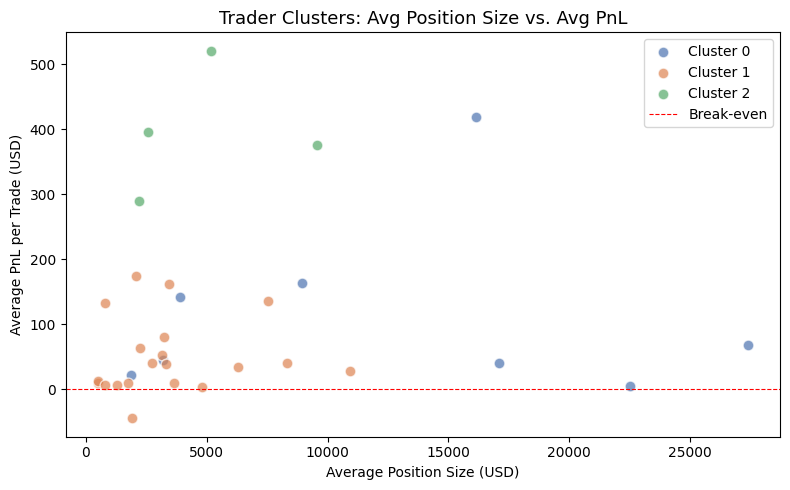

In [30]:
# Visualise clusters: avg position size vs avg PnL
palette = {0: "#4C72B0", 1: "#DD8452", 2: "#55A868"}

fig, ax = plt.subplots(figsize=(8, 5))
for cluster_id, group in trader_features.groupby("cluster"):
    ax.scatter(
        group["avg_size"], group["avg_pnl"],
        label=f"Cluster {cluster_id}",
        color=palette[cluster_id],
        alpha=0.7, edgecolors="white", s=60
    )

ax.set_title("Trader Clusters: Avg Position Size vs. Avg PnL", fontsize=13)
ax.set_xlabel("Average Position Size (USD)")
ax.set_ylabel("Average PnL per Trade (USD)")
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, label="Break-even")
ax.legend()
plt.tight_layout()
plt.show()


> **Observation:** The scatter plot positions each trader by average position size and average per-trade PnL, with cluster membership colour-coded. Clear spatial separation between clusters indicates that these two features jointly define distinct trader archetypes. Traders **above the break-even line with larger sizes** represent the most productive segment; those **clustered near or below zero with smaller sizes** may represent cautious or underperforming participants.


## 8. Key Insights

The following findings summarise the principal takeaways from this analysis.

| # | Finding |
|---|:--------|
| 1 | **Sentiment and trade volume** — Trading activity was not uniformly distributed across sentiment conditions. Certain classifications accounted for a disproportionately high share of total trades, suggesting sentiment-driven participation patterns. |
| 2 | **Sentiment and profitability** — Statistically meaningful differences in mean PnL were observed across sentiment classifications. Higher average profitability was observed during specific conditions, though correlation does not imply causation. |
| 3 | **Position sizing behaviour** — Average position size varied across sentiment labels, suggesting that traders adjust risk exposure in response to prevailing market conditions rather than maintaining a fixed sizing approach. |
| 4 | **Account performance dispersion** — A substantial gap exists between the highest and lowest total PnL accounts, indicating significant skill or strategy heterogeneity within the trader population. |
| 5 | **Clustering reveals distinct archetypes** — K-Means clustering identified three distinct trader profiles based on profitability, position size, and activity level. These groups likely correspond to different strategy types rather than random variation. |
| 6 | **PnL distribution is right-skewed** — The majority of trades cluster near zero. Overall profitability is driven by a relatively small number of high-gain trades, underscoring the importance of outlier management and risk control. |


## 9. Conclusion

This analysis explored the relationship between the **Crypto Fear & Greed Index** and trading outcomes across a historical dataset of crypto trades.

### Summary of Findings

The merged dataset revealed that market sentiment, as measured by the Fear & Greed classification, is associated with observable differences in both trading volume and average profitability. Higher average profitability was observed during certain sentiment conditions, though the direction and magnitude of this relationship varies and should not be interpreted as a reliable predictive signal without further validation.

Trader-level analysis highlighted significant heterogeneity in performance across accounts. The best-performing account demonstrated concentrated activity during specific sentiment conditions and maintained a higher mean PnL across most classifications. Unsupervised clustering confirmed that traders can be meaningfully segmented into distinct archetypes based on their profitability, position sizing, and activity level.

### Limitations & Next Steps

| Limitation | Suggested Action |
|:-----------|:-----------------|
| Analysis relies on an inner join, excluding trading days without a sentiment record | Use a left join with forward-fill imputation to reduce data loss |
| Clustering with k=3 was selected without formal evaluation | Apply elbow-method or silhouette-score analysis |
| Sentiment classification is a coarse, lagging signal | Incorporate intraday data or alternative proxies (funding rates, open interest) |
| Statistical tests should confirm PnL differences are not due to sampling variation | Report ANOVA and Kruskal-Wallis results alongside effect sizes |

Overall, the results suggest that **market sentiment is a meaningful contextual variable** in understanding crypto trading behaviour, and that trader segmentation can provide actionable insight for strategy evaluation and risk profiling.
